# `02_eda_ideal.ipynb` — EDA y análisis de patrones

> **Estado:** continuación directa de `01_limpieza_ideal.ipynb`. No recalcula
> elegibilidad, split, percentiles, score ni categorías. Lee los artefactos
> canónicos de `data/processed/` y los describe.

Este archivo usa el formato *percent* de Jupyter: cada marcador `# %%` es una
celda de código y cada `# %% [markdown]` es una celda Markdown. Para
regenerar el `.ipynb`:

```bash
uvx --from jupytext==1.19.4 jupytext --to ipynb notebooks/02_eda_ideal.py
```

## Stack permitido

- `pandas`, `numpy`, `scipy`, `matplotlib`, `json`, `pathlib`.
- **No permitido aquí:** `seaborn`, `plotly`, `scikit-learn.fit/predict`,
  `joblib`, `pickle`, `onnx`, `FastAPI`, `Flask`, `Spring`, `oci`, cualquier
  import de API o framework de ML/backend.

## Entradas

| Archivo | Filas × columnas | Rol |
|---|---|---|
| `ideal_monthly_features_labeled.parquet` | 555 × 22 | Dataset canónico + etiquetas |
| `ideal_monthly_audit.parquet` | 555 × 11 | Sidecar de auditoría |
| `label_metadata.json` | — | Umbrales, terciles, warnings |
| `ideal_127_viviendas_diario_PRE_PARITY_DEPRECATED.parquet` | — | Legado diario, solo §9.4.13 |

Entorno validado: Python 3.10.0, pandas 2.3.3, numpy 2.2.6, scipy 1.15.3,
matplotlib.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# REPO_ROOT se resuelve desde la ubicación de este script (no desde el CWD),
# de modo que `python3 notebooks/02_eda_ideal.py` y la ejecución como notebook
# apunten al mismo directorio data/processed/.
REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd()
if not (REPO_ROOT / "data" / "processed").is_dir():
    # En kernels Jupyter __file__ no está definido; caer a Path.cwd() y
    # buscar el primer ancestro que contenga data/processed/.
    candidate = Path.cwd()
    for parent in [candidate, *candidate.parents]:
        if (parent / "data" / "processed").is_dir():
            REPO_ROOT = parent
            break
DATA = REPO_ROOT / "data" / "processed"
LABELED = pd.read_parquet(DATA / "ideal_monthly_features_labeled.parquet")
AUDIT = pd.read_parquet(DATA / "ideal_monthly_audit.parquet")
METADATA = json.loads((DATA / "label_metadata.json").read_text())
LEGACY = pd.read_parquet(
    DATA / "ideal_127_viviendas_diario_PRE_PARITY_DEPRECATED.parquet"
)

assert LABELED.shape == (555, 22), f"LABELED shape inesperada: {LABELED.shape}"
assert AUDIT.shape == (555, 11), f"AUDIT shape inesperada: {AUDIT.shape}"
assert not LABELED.duplicated(["homeid", "year_month"]).any(), "LABELED con (homeid, year_month) duplicados."
assert not AUDIT.duplicated(["homeid", "year_month"]).any(), "AUDIT con (homeid, year_month) duplicados."
assert set(map(tuple, LABELED[["homeid", "year_month"]].to_numpy())) == set(
    map(tuple, AUDIT[["homeid", "year_month"]].to_numpy())
), "LABELED y AUDIT no comparten el mismo índice hogar-mes."

pd.set_option("display.max_columns", 60)


def notebook_display(value):
    """Muestra un objeto como DataFrame o lo imprime si no hay display."""
    try:
        from IPython.display import display
        display(value)
    except Exception:
        print(value)


print("Contrato OK — LABELED 555×22, AUDIT 555×11, claves hogar-mes coinciden.")
print(f"Split: {LABELED['split'].value_counts().to_dict()}")
print(f"Categorías: {LABELED['categoria'].value_counts().to_dict()}")

Contrato OK — LABELED 555×22, AUDIT 555×11, claves hogar-mes coinciden.
Split: {'train': 431, 'test': 124}
Categorías: {'Eficiente': 197, 'Moderado': 181, 'Ineficiente': 177}


## 9.4.1 — Calidad y cobertura

Las variables de cobertura determinan el universo de 151 hogares. Cualquier
cambio en el umbral (0,90) modifica ese universo; por eso es la primera
confirmación del notebook.

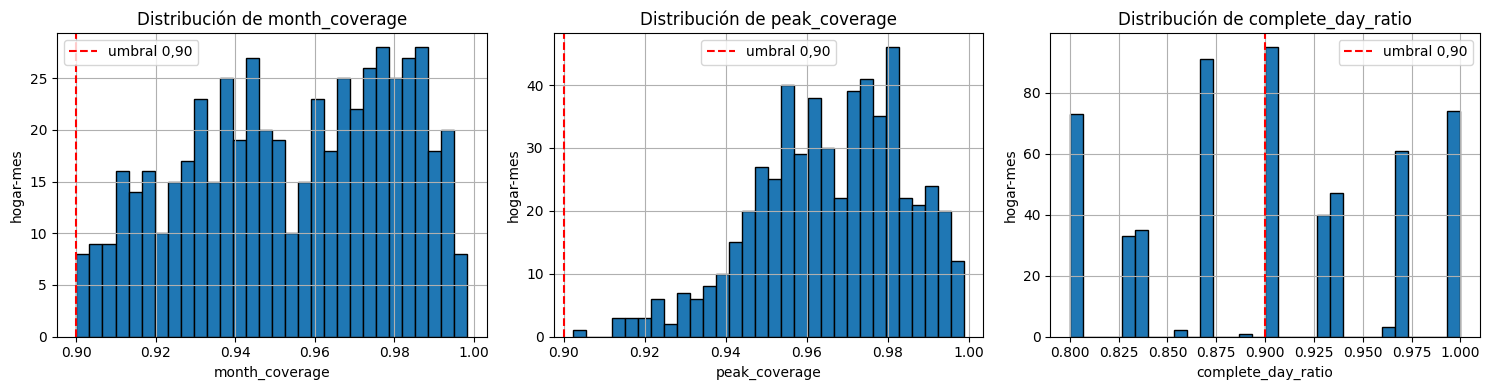

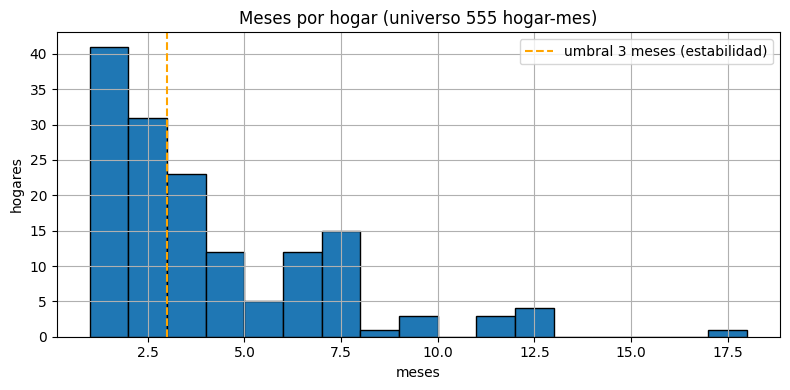

Sensibilidad al umbral de cobertura: 0,90→151 hogares; 0,95→93 hogares.
Conclusión: el universo de 151 hogares y 555 hogar-mes depende explícitamente del umbral 0,90. Subirlo a 0,95 reduciría drásticamente el universo; por eso el umbral se documenta y congela en `category_definition.md` §6.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(
    axes, ["month_coverage", "peak_coverage", "complete_day_ratio"]
):
    LABELED[col].dropna().hist(bins=30, ax=ax, edgecolor="black")
    ax.axvline(0.90, color="red", linestyle="--", label="umbral 0,90")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("hogar-mes")
    ax.legend()
plt.tight_layout()
plt.show()

months_per_home = LABELED.groupby("homeid").size()
fig, ax = plt.subplots(figsize=(8, 4))
months_per_home.hist(bins=range(1, months_per_home.max() + 2), ax=ax, edgecolor="black")
ax.axvline(3, color="orange", linestyle="--", label="umbral 3 meses (estabilidad)")
ax.set_title("Meses por hogar (universo 555 hogar-mes)")
ax.set_xlabel("meses")
ax.set_ylabel("hogares")
ax.legend()
plt.tight_layout()
plt.show()

_cov = METADATA.get("monthly_quality", {}).get("coverage_sensitivity", {})
print(
    "Sensibilidad al umbral de cobertura: "
    f"0,90→{_cov.get('0.90', {}).get('homes', 's/D')} hogares; "
    f"0,95→{_cov.get('0.95', {}).get('homes', 's/D')} hogares."
)
print(
    "Conclusión: el universo de 151 hogares y 555 hogar-mes depende explícitamente "
    "del umbral 0,90. Subirlo a 0,95 reduciría drásticamente el universo; por "
    "eso el umbral se documenta y congela en `category_definition.md` §6."
)

## 9.4.2 — Distribución de consumo por tipo de inmueble

El consumo mensual ajustado por cobertura es la variable principal del
endpoint. Su distribución difiere marcadamente entre casas y departamentos.

,filas,median,mean,min,max,IQR,hogares
tipo_inmueble,,,,,,,
Casa,237,285.34,298.37,92.08,812.26,118.37,67
Departamento,318,199.59,222.79,61.99,646.30,119.43,84


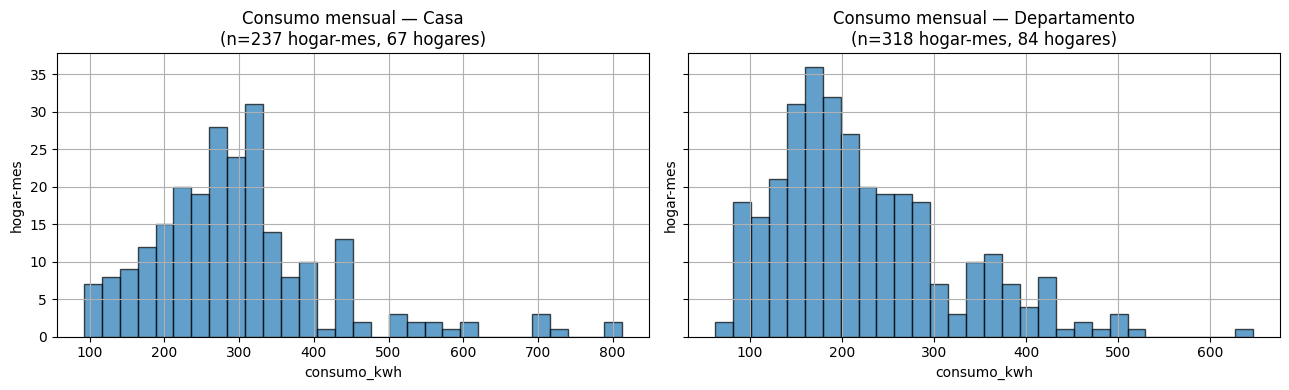

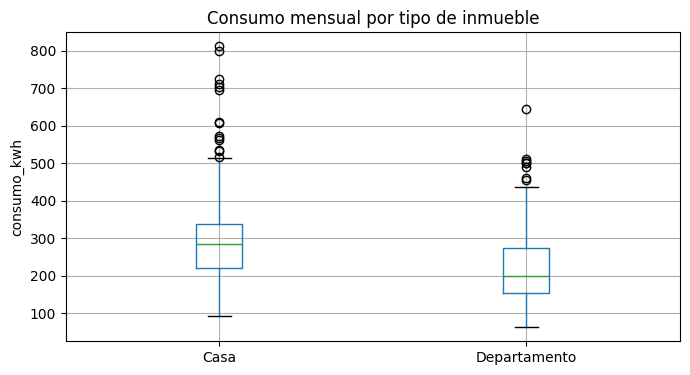

In [3]:
summary = (
    LABELED.groupby("tipo_inmueble")["consumo_kwh"]
    .agg(["count", "median", "mean", "min", "max"])
    .assign(
        IQR=lambda d: (
            LABELED.groupby("tipo_inmueble")["consumo_kwh"].quantile(0.75)
            - LABELED.groupby("tipo_inmueble")["consumo_kwh"].quantile(0.25)
        ).values
    )
    .assign(hogares=lambda d: LABELED.groupby("tipo_inmueble")["homeid"].nunique().values)
    .rename(columns={"count": "filas"})
)
notebook_display(summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, tipo in zip(axes, ["Casa", "Departamento"]):
    subset = LABELED[LABELED["tipo_inmueble"] == tipo]
    subset["consumo_kwh"].hist(bins=30, ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title(f"Consumo mensual — {tipo}\n(n={len(subset)} hogar-mes, "
                 f"{subset['homeid'].nunique()} hogares)")
    ax.set_xlabel("consumo_kwh")
    ax.set_ylabel("hogar-mes")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
LABELED.boxplot(column="consumo_kwh", by="tipo_inmueble", ax=ax, showfliers=True)
ax.set_title("Consumo mensual por tipo de inmueble")
ax.set_ylabel("consumo_kwh")
ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 9.4.3 — Diferencias entre viviendas (sin pseudorreplicación)

Los 555 hogar-mes provienen de 151 viviendas. Tratar cada fila como
independiente inflaría la potencia estadística. Aquí agregamos primero por
hogar para comparar distribuciones a nivel vivienda.

N hogares (train): 113
              consumo_medio                                                  \
                      count    mean     std     min     25%     50%     75%   
tipo_inmueble                                                                 
Casa                   50.0  298.23  100.38  132.22  231.50  277.16  338.90   
Departamento           63.0  219.41   90.65   85.59  157.33  197.61  261.88   

                      cantidad_equipos                                     \
                  max            count   mean   std  min  25%   50%   75%   
tipo_inmueble                                                               
Casa           582.93             50.0  11.22  3.15  4.0  9.0  11.0  13.0   
Departamento   550.98             63.0   9.48  3.50  3.0  7.0   9.0  12.0   

                     
                max  
tipo_inmueble        
Casa           18.0  
Departamento   19.0  


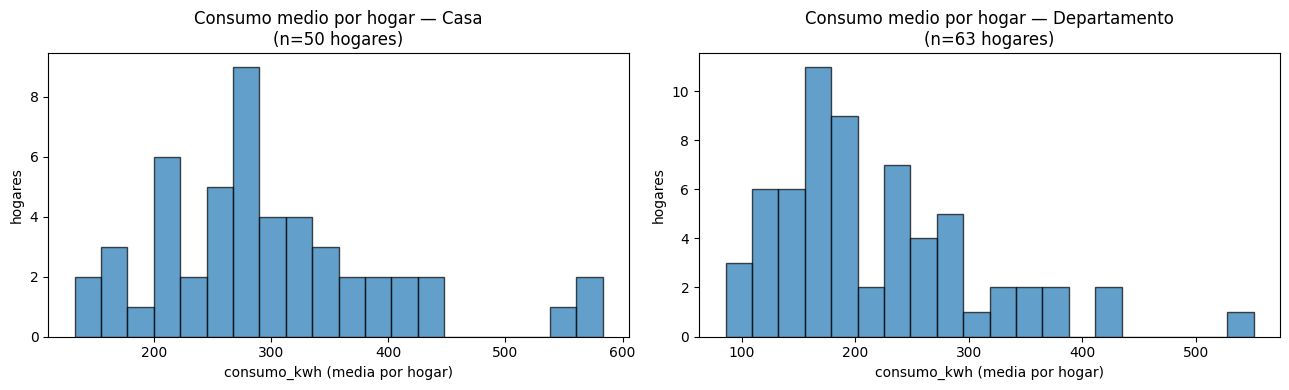

Conclusión: la dispersión a nivel hogar es mucho menor que la observada a nivel hogar-mes. Cualquier inferencia debe respetar la unidad de agrupación (homeid).


In [4]:
home_level = (
    LABELED[LABELED["split"] == "train"]
    .groupby(["homeid", "tipo_inmueble"])
    .agg(
        consumo_medio=("consumo_kwh", "mean"),
        consumo_std=("consumo_kwh", "std"),
        cantidad_equipos=("cantidad_equipos", "first"),
        meses=("year_month", "nunique"),
    )
    .reset_index()
)
print(f"N hogares (train): {len(home_level)}")
print(home_level.groupby("tipo_inmueble")[["consumo_medio", "cantidad_equipos"]]
      .describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tipo in zip(axes, ["Casa", "Departamento"]):
    subset = home_level[home_level["tipo_inmueble"] == tipo]
    ax.hist(subset["consumo_medio"], bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"Consumo medio por hogar — {tipo}\n(n={len(subset)} hogares)")
    ax.set_xlabel("consumo_kwh (media por hogar)")
    ax.set_ylabel("hogares")
plt.tight_layout()
plt.show()
print(
    "Conclusión: la dispersión a nivel hogar es mucho menor que la observada "
    "a nivel hogar-mes. Cualquier inferencia debe respetar la unidad de "
    "agrupación (homeid)."
)

## 9.4.4 — Categorías

Las pseudoetiquetas son terciles del score dentro de train, replicados a
test con los mismos cortes `t1` y `t2`. El equilibrio entre clases en
train es consecuencia metodológica de usar terciles, **no es validación
científica de las categorías**.

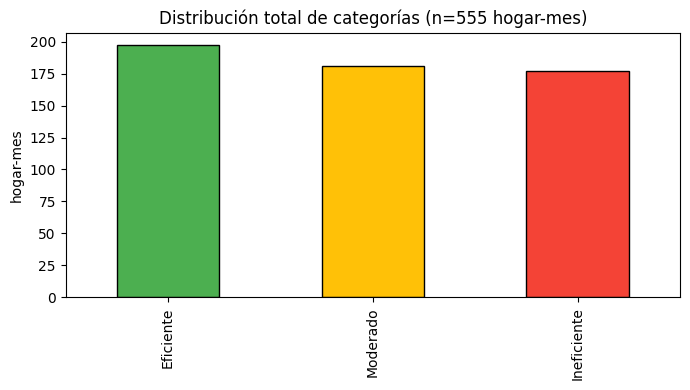

Conteo por split:


categoria,Eficiente,Moderado,Ineficiente
split,,,
test,53,38,33
train,144,143,144


Conteo por tipo_inmueble:


categoria,Eficiente,Moderado,Ineficiente
tipo_inmueble,,,
Casa,77,70,90
Departamento,120,111,87


Cortes congelados: t1=0.362951, t2=0.611135.
Interpretación: el balance de train (~1/3 por clase) sigue del uso de terciles. Test hereda los cortes congelados y puede desbalancearse; esto es esperado y no incumple el contrato metodológico.


In [5]:
class_total = LABELED["categoria"].value_counts().reindex(
    ["Eficiente", "Moderado", "Ineficiente"], fill_value=0
)
fig, ax = plt.subplots(figsize=(7, 4))
class_total.plot.bar(ax=ax, edgecolor="black", color=["#4CAF50", "#FFC107", "#F44336"])
ax.set_title(f"Distribución total de categorías (n={class_total.sum()} hogar-mes)")
ax.set_ylabel("hogar-mes")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

crosstab_split = pd.crosstab(LABELED["split"], LABELED["categoria"]).reindex(
    columns=["Eficiente", "Moderado", "Ineficiente"], fill_value=0
)
crosstab_type = pd.crosstab(LABELED["tipo_inmueble"], LABELED["categoria"]).reindex(
    columns=["Eficiente", "Moderado", "Ineficiente"], fill_value=0
)
print("Conteo por split:")
notebook_display(crosstab_split)
print("Conteo por tipo_inmueble:")
notebook_display(crosstab_type)

print(
    f"Cortes congelados: t1={METADATA['thresholds']['t1']:.6f}, "
    f"t2={METADATA['thresholds']['t2']:.6f}."
)
print(
    "Interpretación: el balance de train (~1/3 por clase) sigue del uso de "
    "terciles. Test hereda los cortes congelados y puede desbalancearse; esto "
    "es esperado y no incumple el contrato metodológico."
)

## 9.4.5 — Horario pico

Se operacionaliza "horario de mayor consumo" como la ventana **definida**
17:00–21:00 hora local (`Europe/London`, ajustada por DST). No se pretende
identificar la hora exacta de máximo consumo de cada hogar.

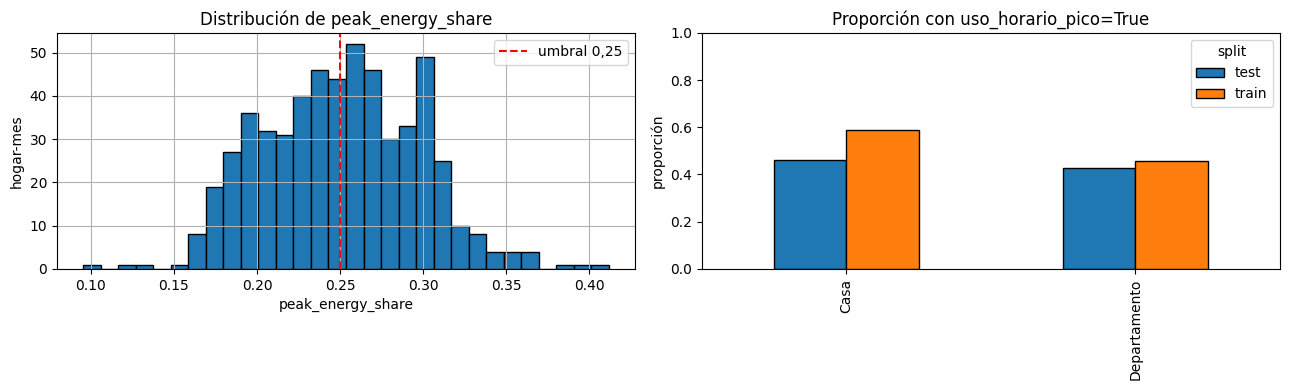

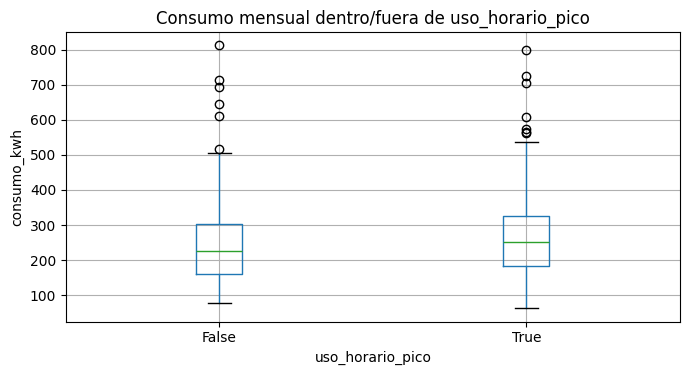

Limitación: la ventana 17:00–21:00 es una convención fija del endpoint. Hogares con patrón pico desplazado (p. ej. turno nocturno) pueden tener bajo peak_energy_share sin ser eficientes.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
LABELED["peak_energy_share"].hist(bins=30, ax=axes[0], edgecolor="black")
axes[0].axvline(0.25, color="red", linestyle="--", label="umbral 0,25")
axes[0].set_title("Distribución de peak_energy_share")
axes[0].set_xlabel("peak_energy_share")
axes[0].set_ylabel("hogar-mes")
axes[0].legend()

peak_prop = (
    LABELED.assign(uso_pico=LABELED["uso_horario_pico"])
    .groupby(["split", "tipo_inmueble"])["uso_pico"]
    .mean()
    .unstack("split")
)
peak_prop.plot.bar(ax=axes[1], edgecolor="black")
axes[1].set_title("Proporción con uso_horario_pico=True")
axes[1].set_ylabel("proporción")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
LABELED.boxplot(
    column="consumo_kwh", by="uso_horario_pico", ax=ax, showfliers=True
)
ax.set_title("Consumo mensual dentro/fuera de uso_horario_pico")
ax.set_xlabel("uso_horario_pico")
ax.set_ylabel("consumo_kwh")
plt.suptitle("")
plt.tight_layout()
plt.show()
print(
    "Limitación: la ventana 17:00–21:00 es una convención fija del endpoint. "
    "Hogares con patrón pico desplazado (p. ej. turno nocturno) pueden tener "
    "bajo peak_energy_share sin ser eficientes."
)

## 9.4.6 — Potencia y consumo nocturno

Estas variables provienen del sidecar `AUDIT`, no de las 5 features del
modelo. La separación asegura que ninguna variable adicional entre al score.
La **potencia máxima** es sensible a picos transitorios y no debe
interpretarse como un resumen estable del hogar.

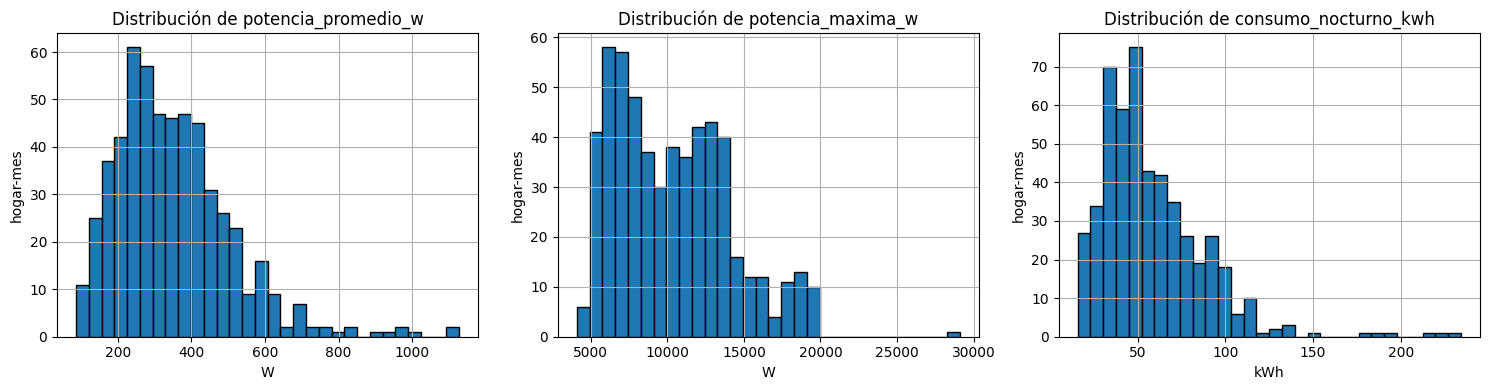

night_eligible=True en 90.6% de los hogar-mes.


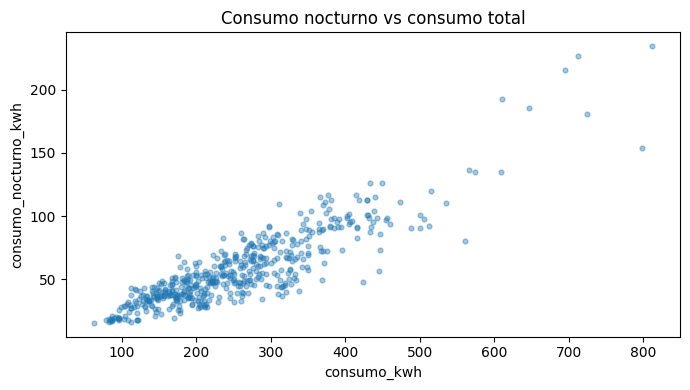

Advertencia: potencia_maxima_w es sensible a un único pico de 1 segundo y no entra en la etiqueta. No debe usarse como feature del modelo ni como criterio de categorización.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, xlabel in zip(
    axes,
    ["potencia_promedio_w", "potencia_maxima_w", "consumo_nocturno_kwh"],
    ["W", "W", "kWh"],
):
    AUDIT[col].dropna().hist(bins=30, ax=ax, edgecolor="black")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("hogar-mes")
plt.tight_layout()
plt.show()

night_eligible_pct = AUDIT["night_eligible"].mean() * 100
print(f"night_eligible=True en {night_eligible_pct:.1f}% de los hogar-mes.")

merged = LABELED.merge(
    AUDIT[["homeid", "year_month", "consumo_nocturno_kwh"]],
    on=["homeid", "year_month"],
    how="inner",
    validate="one_to_one",
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(merged["consumo_kwh"], merged["consumo_nocturno_kwh"], alpha=0.4, s=12)
ax.set_title("Consumo nocturno vs consumo total")
ax.set_xlabel("consumo_kwh")
ax.set_ylabel("consumo_nocturno_kwh")
plt.tight_layout()
plt.show()
print(
    "Advertencia: potencia_maxima_w es sensible a un único pico de 1 segundo "
    "y no entra en la etiqueta. No debe usarse como feature del modelo ni "
    "como criterio de categorización."
)

## 9.4.7 — Valores atípicos

Detección descriptiva mediante método IQR sobre cuatro variables clave.
La política de no eliminación se declara en la conclusión de la celda.

In [8]:
outlier_limits = {}
for col in ["consumo_kwh", "potencia_maxima_w", "peak_energy_share", "horas_alto_consumo"]:
    if col in LABELED.columns:
        series = LABELED[col].dropna()
    elif col in AUDIT.columns:
        series = AUDIT[col].dropna()
    else:
        continue
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_limits[col] = (lower, upper, series.index[(series < lower) | (series > upper)])

for col, (lower, upper, idx) in outlier_limits.items():
    if col in LABELED.columns:
        bad = LABELED.loc[idx, ["homeid", "year_month", col]].copy()
    else:
        bad = AUDIT.loc[idx, ["homeid", "year_month", col]].copy()
    print(f"{col}: {len(bad)} hogar-mes fuera de [{lower:.3f}, {upper:.3f}]")
    if len(bad):
        notebook_display(bad.head(5))
print(
    "Conclusión: los outliers se listan pero no se eliminan, para preservar "
    "la reproducibilidad del pipeline (ver category_definition.md §13)."
)

consumo_kwh: 14 hogar-mes fuera de [-40.700, 527.716]


,homeid,year_month,consumo_kwh
328,146,2017-08,712.385334
329,146,2017-09,694.996440
330,146,2017-10,610.451335
331,146,2017-11,812.264787
345,156,2017-11,646.300117


potencia_maxima_w: 1 hogar-mes fuera de [-1421.250, 21228.750]


,homeid,year_month,potencia_maxima_w
202,97,2017-10,29107.0


peak_energy_share: 3 hogar-mes fuera de [0.109, 0.391]


,homeid,year_month,peak_energy_share
262,118,2017-11,0.411813
297,124,2018-04,0.095336
389,170,2017-11,0.392263


horas_alto_consumo: 18 hogar-mes fuera de [-4.000, 12.000]


,homeid,year_month,horas_alto_consumo
132,74,2017-02,13
141,74,2017-11,13
282,122,2018-03,13
323,144,2017-08,13
324,144,2017-09,14


Conclusión: los outliers se listan pero no se eliminan, para preservar la reproducibilidad del pipeline (ver category_definition.md §13).


## 9.4.8 — Variación entre períodos

Solo comparaciones entre meses calendario consecutivos. Pivotear la tabla
hogar-mes para analizar estacionariedad sería inapropiado por cobertura
heterogénea entre hogares.

Hogares con al menos un par consecutivo: 84


,homeid,var_abs_media,var_pct_media,n_transiciones_cat,n_pares
count,84.000,84.000,84.000,84.000,84.000
mean,151.524,-2.850,0.800,0.655,3.119
std,69.939,39.025,12.334,1.012,2.534
min,59.000,-230.873,-32.797,0.000,1.000
25%,95.500,-13.816,-6.437,0.000,1.000
50%,137.500,1.898,1.242,0.000,2.000
75%,189.500,12.521,6.321,1.000,4.000
max,300.000,95.640,46.801,5.000,14.000


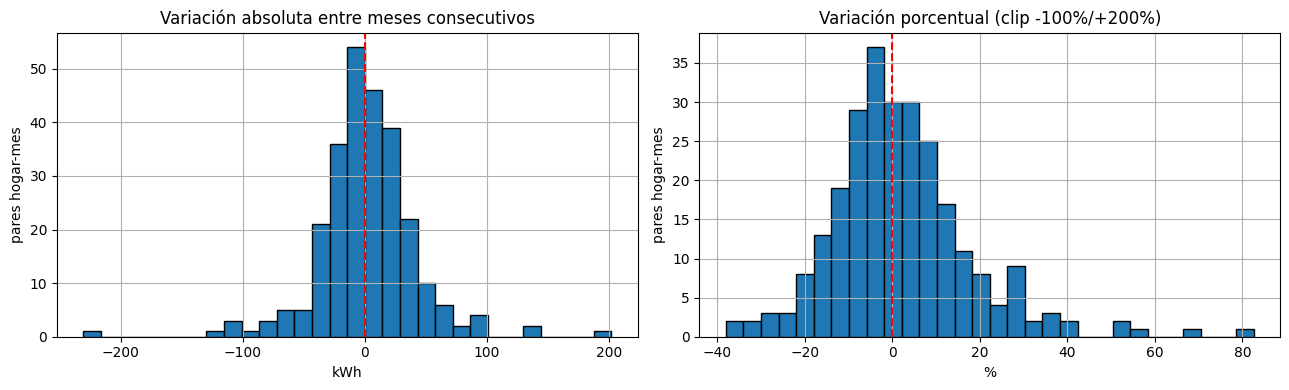

Resumen por hogar sobre pares consecutivos. La agregación respeta la unidad vivienda: no se promedian pares de hogares distintos.


In [9]:
ordered = LABELED.sort_values(["homeid", "year_month"]).copy()
ordered["month"] = pd.PeriodIndex(ordered["year_month"], freq="M")
ordered["prev_month"] = ordered.groupby("homeid")["month"].shift(1)
ordered["prev_consumo"] = ordered.groupby("homeid")["consumo_kwh"].shift(1)
ordered["prev_cat"] = ordered.groupby("homeid")["categoria"].shift(1)
ordered["consecutive"] = ordered.apply(
    lambda r: False if pd.isna(r["prev_month"])
    else (r["month"] - r["prev_month"]).n == 1, axis=1
)
consec = ordered[ordered["consecutive"]].copy()
consec["variacion_absoluta_kwh"] = consec["consumo_kwh"] - consec["prev_consumo"]
consec["variacion_porcentual_kwh"] = (
    consec["variacion_absoluta_kwh"] / consec["prev_consumo"]
) * 100
consec["cambio_de_categoria"] = consec["categoria"] != consec["prev_cat"]

per_home = consec.groupby("homeid").agg(
    var_abs_media=("variacion_absoluta_kwh", "mean"),
    var_pct_media=("variacion_porcentual_kwh", "mean"),
    n_transiciones_cat=("cambio_de_categoria", "sum"),
    n_pares=("year_month", "size"),
).reset_index()
print(f"Hogares con al menos un par consecutivo: {len(per_home)}")
notebook_display(per_home.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
consec["variacion_absoluta_kwh"].hist(bins=30, ax=axes[0], edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Variación absoluta entre meses consecutivos")
axes[0].set_xlabel("kWh")
axes[0].set_ylabel("pares hogar-mes")
consec["variacion_porcentual_kwh"].clip(-100, 200).hist(
    bins=30, ax=axes[1], edgecolor="black"
)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Variación porcentual (clip -100%/+200%)")
axes[1].set_xlabel("%")
axes[1].set_ylabel("pares hogar-mes")
plt.tight_layout()
plt.show()
print(
    "Resumen por hogar sobre pares consecutivos. La agregación respeta la "
    "unidad vivienda: no se promedian pares de hogares distintos."
)

## 9.4.9 — Estabilidad temporal

Para hogares con tres o más meses, contamos transiciones de categoría y
saltos extremos (Eficiente↔Ineficiente). Los warnings del JSON informan
sobre baja potencia o alta inestabilidad.

In [10]:
months_per_home = ordered.groupby("homeid").size()
homes_3plus = months_per_home[months_per_home >= 3].index
trans_count = consec.groupby("homeid")["cambio_de_categoria"].sum().reindex(
    homes_3plus, fill_value=0
)

ordinal = {"Eficiente": 0, "Moderado": 1, "Ineficiente": 2}
consec["cat_ord"] = consec["categoria"].map(ordinal)
consec["prev_cat_ord"] = consec["prev_cat"].map(ordinal)
consec["delta_cat"] = (consec["cat_ord"] - consec["prev_cat_ord"]).abs()
extreme_jump = consec[consec["delta_cat"] == 2]

_diag = METADATA.get("diagnostics", {})
print(f"Hogares con ≥3 meses: {len(homes_3plus)}")
print(f"Mediana de transiciones por hogar: {trans_count.median():.1f}")
print(f"Proporción con ≥2 transiciones: {(trans_count >= 2).mean():.3f}")
print(
    f"Proporción con salto extremo (E↔I): "
    f"{len(extreme_jump.groupby('homeid')) / max(len(homes_3plus),1):.3f}"
)
print(
    f"warnings JSON: stability={_diag.get('temporal_stability_warning')}, "
    f"low_power={_diag.get('temporal_stability_low_power')}"
)
print(
    "Conclusión: un nivel moderado de transiciones es esperable por la "
    "definición relativa de terciles; los saltos extremos son minoría y "
    "conviene revisarlos caso por caso antes de cualquier seguimiento."
)

Hogares con ≥3 meses: 79
Mediana de transiciones por hogar: 0.0
Proporción con ≥2 transiciones: 0.165
Proporción con salto extremo (E↔I): 0.038
warnings JSON: stability=False, low_power=False
Conclusión: un nivel moderado de transiciones es esperable por la definición relativa de terciles; los saltos extremos son minoría y conviene revisarlos caso por caso antes de cualquier seguimiento.


## 9.4.10 — Coherencia Spearman

Relaciones ordinales entre la categoría (0/1/2) y variables del score o de
cobertura. Son **descriptivas**, no validación externa. Las 555 filas son
hogar-mes: los hogares con más meses pesan más, así que estos coeficientes
no son equivalentes a una correlación entre 555 viviendas independientes.

In [11]:
LABELED_ = LABELED.copy()
LABELED_["cat_ord"] = LABELED_["categoria"].map(ordinal)

def safe_spearman(a, b):
    valid = pd.concat([a, b], axis=1).dropna()
    if len(valid) < 3 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
        return None
    return float(spearmanr(valid.iloc[:, 0], valid.iloc[:, 1]).statistic)

pairs = [
    ("cat_ord vs peak_energy_share", LABELED_["cat_ord"], LABELED_["peak_energy_share"]),
    ("cat_ord vs month_coverage", LABELED_["cat_ord"], LABELED_["month_coverage"]),
    ("cat_ord vs cantidad_equipos", LABELED_["cat_ord"], LABELED_["cantidad_equipos"]),
]
for name, a, b in pairs:
    print(f"Spearman {name}: {safe_spearman(a, b)}")

print(
    "Interpretación: consumo, pico y horas altas tienen circularidad directa "
    "con la categoría (forman el score). `cantidad_equipos` pesa solo 5% en "
    "el score; su correlación con categoría es esperablemente débil. "
    "`month_coverage` no debería correlacionarse con la categoría (la "
    "categoría se construye tras aplicar el umbral de cobertura)."
)

Spearman cat_ord vs peak_energy_share: 0.3351000856862795
Spearman cat_ord vs month_coverage: 0.19039804172790636
Spearman cat_ord vs cantidad_equipos: 0.16458992709380552
Interpretación: consumo, pico y horas altas tienen circularidad directa con la categoría (forman el score). `cantidad_equipos` pesa solo 5% en el score; su correlación con categoría es esperablemente débil. `month_coverage` no debería correlacionarse con la categoría (la categoría se construye tras aplicar el umbral de cobertura).


## 9.4.11 — Equipos frente a consumo

Solo train, una observación por hogar. Las correlaciones a nivel hogar-mes
exagerarían el n efectivo.

train_counts_by_type (de references): {'Casa': 50, 'Departamento': 63}


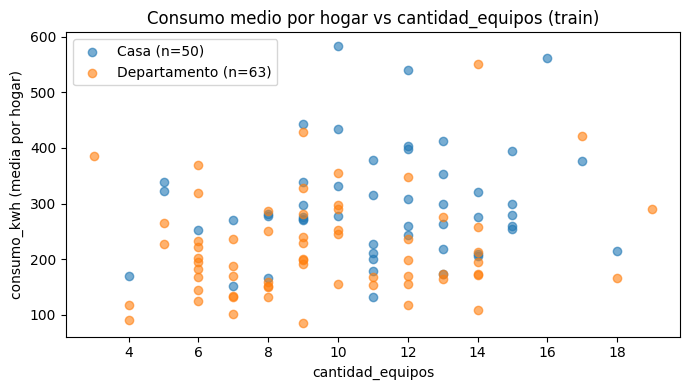

Casa: Spearman=0.08966644196914146, Pearson=0.13978133248433933
Departamento: Spearman=0.13220895745132166, Pearson=0.1555808089809657
Limitación: la cantidad de equipos declarados puede no captar consumo real (uso, antigüedad, eficiencia). Esta correlación débil es esperable y justifica los pesos del score (5% para equipos).


In [12]:
home_train = (
    LABELED[LABELED["split"] == "train"]
    .groupby(["homeid", "tipo_inmueble"])
    .agg(
        consumo_medio=("consumo_kwh", "mean"),
        cantidad_equipos=("cantidad_equipos", "first"),
    )
    .reset_index()
)
_refs = METADATA.get("references", {})
counts_by_type = {
    k: v.get("equipos_n_train_homes") for k, v in _refs.items()
    if isinstance(v, dict)
}
print(f"train_counts_by_type (de references): {counts_by_type}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"Casa": "tab:blue", "Departamento": "tab:orange"}
for tipo, sub in home_train.groupby("tipo_inmueble"):
    ax.scatter(sub["cantidad_equipos"], sub["consumo_medio"],
               label=f"{tipo} (n={len(sub)})", alpha=0.6, c=colors.get(tipo, "gray"))
ax.set_title("Consumo medio por hogar vs cantidad_equipos (train)")
ax.set_xlabel("cantidad_equipos")
ax.set_ylabel("consumo_kwh (media por hogar)")
ax.legend()
plt.tight_layout()
plt.show()

for tipo, sub in home_train.groupby("tipo_inmueble"):
    rho = safe_spearman(sub["cantidad_equipos"], sub["consumo_medio"])
    valid = pd.concat([sub["cantidad_equipos"], sub["consumo_medio"]], axis=1).dropna()
    r = None
    if len(valid) >= 3 and valid.iloc[:, 0].nunique() > 1 and valid.iloc[:, 1].nunique() > 1:
        r = float(pearsonr(valid.iloc[:, 0], valid.iloc[:, 1]).statistic)
    print(f"{tipo}: Spearman={rho}, Pearson={r}")
print(
    "Limitación: la cantidad de equipos declarados puede no captar consumo "
    "real (uso, antigüedad, eficiencia). Esta correlación débil es esperable "
    "y justifica los pesos del score (5% para equipos)."
)

## 9.4.12 — Densidad alrededor de terciles

Si muchas observaciones caen muy cerca de `t1` o `t2`, pequeños cambios en
los cortes desplazarían muchas categorías. Aquí se mide esa sensibilidad
local.

Scores únicos (train): 431
 en ±0.02 de t1 (0.362951): 26 (6.03%)
 en ±0.02 de t2 (0.611135): 16 (3.71%)


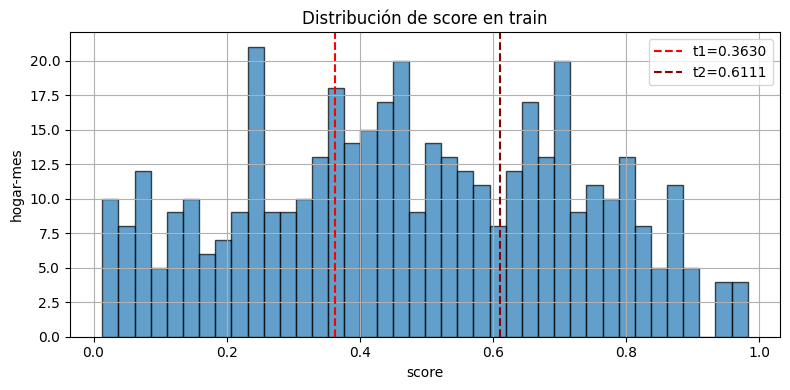

Conclusión: una baja proporción cerca de los cortes indica que el categorizador es estable a pequeñas perturbaciones del conjunto de train.


In [13]:
t1, t2 = METADATA["thresholds"]["t1"], METADATA["thresholds"]["t2"]
train_scores = LABELED[LABELED["split"] == "train"]["score"].dropna().unique()
n_train = len(train_scores)
eps = 0.02
near_t1 = (np.abs(train_scores - t1) < eps).sum()
near_t2 = (np.abs(train_scores - t2) < eps).sum()
print(f"Scores únicos (train): {n_train}")
print(f" en ±{eps} de t1 ({t1:.6f}): {near_t1} ({near_t1/max(n_train,1)*100:.2f}%)")
print(f" en ±{eps} de t2 ({t2:.6f}): {near_t2} ({near_t2/max(n_train,1)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
LABELED[LABELED["split"] == "train"]["score"].dropna().hist(
    bins=40, ax=ax, edgecolor="black", alpha=0.7
)
ax.axvline(t1, color="red", linestyle="--", label=f"t1={t1:.4f}")
ax.axvline(t2, color="darkred", linestyle="--", label=f"t2={t2:.4f}")
ax.set_title("Distribución de score en train")
ax.set_xlabel("score")
ax.set_ylabel("hogar-mes")
ax.legend()
plt.tight_layout()
plt.show()
print(
    "Conclusión: una baja proporción cerca de los cortes indica que el "
    "categorizador es estable a pequeñas perturbaciones del conjunto de train."
)

## 9.4.13 — Evolución diaria como continuidad histórica

> Esta vista conserva y extiende el análisis diario previo. El archivo
> utiliza 127 hogares y el criterio histórico de `horas_registradas
> >= 20`; no está corregido con la metodología hogar-mes y no alimenta las
> variables, scores ni categorías oficiales.

Legado: 30732 filas, 127 hogares.
Columnas potencialmente usables: ['fecha', 'potencia_promedio', 'potencia_maxima']


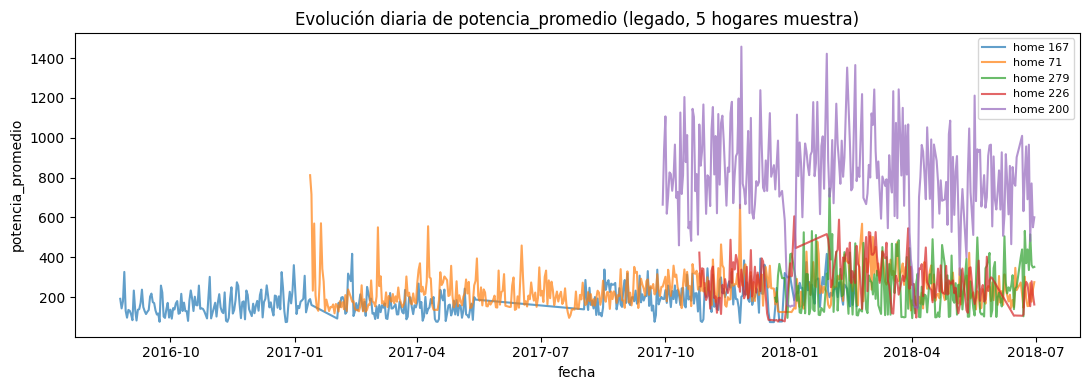

Nota: el legado no se utiliza para scoring ni categorización. Se preserva solo como antecedente exploratorio (ver `01_limpieza_ideal_previo.ipynb`).


In [14]:
print(f"Legado: {len(LEGACY)} filas, {LEGACY['home_id'].nunique()} hogares.")
relevant = [
    c for c in LEGACY.columns
    if "potencia" in c.lower() or "consumo" in c.lower() or "fecha" in c.lower()
]
print(f"Columnas potencialmente usables: {relevant[:10]}")

date_col = next((c for c in LEGACY.columns if "fecha" in c.lower() or "date" in c.lower()), None)
power_col = next(
    (c for c in LEGACY.columns if "potencia_promedio" in c.lower()
     or c.lower() == "potencia_promedio"), None
)
if date_col and power_col:
    LEGACY[date_col] = pd.to_datetime(LEGACY[date_col], errors="coerce")
    sample_homes = LEGACY["home_id"].drop_duplicates().sample(
        min(5, LEGACY["home_id"].nunique()), random_state=42
    ).tolist()
    fig, ax = plt.subplots(figsize=(11, 4))
    for hid in sample_homes:
        sub = LEGACY[LEGACY["home_id"] == hid].sort_values(date_col)
        ax.plot(sub[date_col], sub[power_col], label=f"home {hid}", alpha=0.7)
    ax.set_title(f"Evolución diaria de {power_col} (legado, 5 hogares muestra)")
    ax.set_xlabel("fecha")
    ax.set_ylabel(power_col)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No se identificaron columnas de fecha/potencia en el legado.")

daily_agg = (
    LEGACY.groupby(LEGACY[date_col] if date_col else LEGACY.columns[0])
    .size() if date_col else None
)
print(
    "Nota: el legado no se utiliza para scoring ni categorización. Se "
    "preserva solo como antecedente exploratorio (ver "
    "`01_limpieza_ideal_previo.ipynb`)."
)

## 9.4.14 — Limitaciones y frontera de responsabilidades

## Limitaciones y delegación

El entrenamiento y la serialización del clasificador se delegan al equipo
de Data Science. La entrada prevista son las cinco variables canónicas:

- `consumo_kwh`
- `uso_horario_pico`
- `cantidad_equipos`
- `tipo_inmueble`
- `horas_alto_consumo`

La salida esperada es `{categoria, probabilidad}`. Para una evaluación
posterior, todas las filas de una misma vivienda deben permanecer en el
mismo fold mediante `GroupKFold` o `StratifiedGroupKFold` (con `homeid`
como grupo). **No se deben recalcular percentiles ni terciles en
inferencia**: el endpoint aplica el preprocesador y clasificador
entrenados.

Este notebook no entrena, evalúa ni serializa modelos. Tampoco implementa
API, OCI, ni frontend.